## Unsupervised Learning & K-Means
***Week 5 - Day 1***

**Step 1: Load and scale a provided dataset (numeric features only) with StandardScaler.**

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [25]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [26]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


we have in this dataset 3 numerical values which we can cluster.
also we have 200 row and 5 features, we can see that there is no missing values.

In [28]:
df_num = df[["Age","Annual Income (k$)", "Spending Score (1-100)"]]
df_num.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [29]:
scaler = MinMaxScaler()
scaler.fit(df_num[["Age", "Annual Income (k$)", "Spending Score (1-100)"]])
X_scaled = scaler.transform(df_num[["Age", "Annual Income (k$)", "Spending Score (1-100)"]])

X_scaled_df = pd.DataFrame(X_scaled, columns=["Age", "Annual Income (k$)", "Spending Score (1-100)"])
X_scaled_df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,0.019231,0.000000,0.387755
1,0.057692,0.000000,0.816327
2,0.038462,0.008197,0.051020
3,0.096154,0.008197,0.775510
4,0.250000,0.016393,0.397959


**Step 2: Run K-Means for k from 1 to 10 and plot inertia to find the elbow.**

In [30]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled_df)
print(labels) 

[1 1 2 1 1 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0
 1 0 1 0 1 0 1 0 1 0 1 1 1 0 1 1 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0
 0 1 0 0 1 0 0 1 0 0 1 0 0 1 1 0 0 1 0 0 1 1 0 1 0 1 1 0 0 1 0 1 0 0 0 0 0
 1 2 1 1 1 0 0 0 0 1 2 1 1 2 1 2 1 0 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 0 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1]


In [31]:
X_scaled_df['cluster'] = labels
X_scaled_df.head()

,Age,Annual Income (k$),Spending Score (1-100),cluster
0,0.019231,0.000000,0.387755,1
1,0.057692,0.000000,0.816327,1
2,0.038462,0.008197,0.051020,2
3,0.096154,0.008197,0.775510,1
4,0.250000,0.016393,0.397959,1


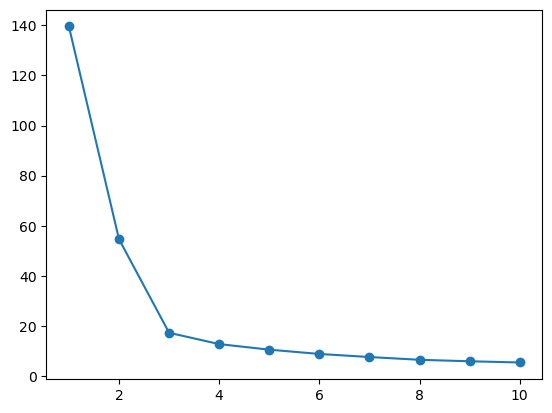

In [32]:
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled_df)
    inertias.append(km.inertia_)
plt.plot(range(1, 11), inertias, marker="o")
plt.show()

This graph helps pick the best number of clusters (k). As k increases, the error (inertia) goes down. But after k=3, the line becomes flat — adding more clusters doesn't help much anymore. This bend is called the "elbow," so I choose k=3.

**Step 3: Compute the silhouette score for the top two candidate k values and pick the best.**

In [33]:
km2 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels2 = km2.fit_predict(X_scaled_df)
score2 = silhouette_score(X_scaled_df, labels2)

km3 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels3 = km3.fit_predict(X_scaled_df)
score3 = silhouette_score(X_scaled_df, labels3)

print("Silhouette score for k=2:", score2)
print("Silhouette score for k=3:", score3)

Silhouette score for k=2: 0.6883966805877983
Silhouette score for k=3: 0.5838382515168817


We compared k=3 and k=4 using the silhouette score. K=3 got a higher score (0.688) than k=4 (0.584). A higher score means better-separated clusters, so k=3 is the better choice. This also matches what we saw in the elbow method.

**Step 4: Fit final K-Means with the chosen k, and visualize the clusters on a 2D scatter plot.**

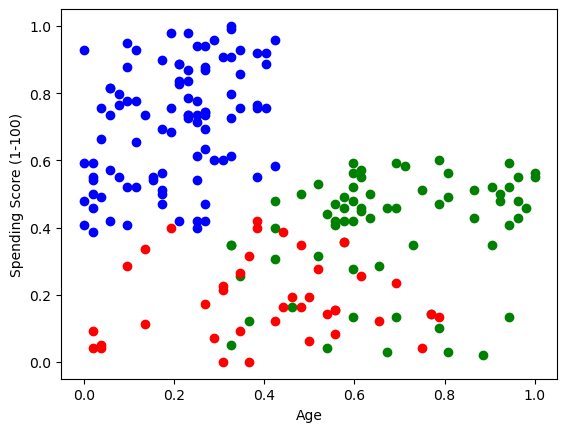

In [34]:
df1 = X_scaled_df[X_scaled_df.cluster==0]
df2 = X_scaled_df[X_scaled_df.cluster==1]
df3 = X_scaled_df[X_scaled_df.cluster==2]

plt.scatter(df1["Age"], df1["Spending Score (1-100)"], color='green')
plt.scatter(df2["Age"], df2["Spending Score (1-100)"], color='blue')
plt.scatter(df3["Age"], df3["Spending Score (1-100)"], color='red')

plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.show()

The K-Means algorithm grouped mall customers into 3 segments based on their Age and Spending Score:

Cluster 0 (Green): Young Big Spenders, Mostly younger customers with a high spending score. They spend a lot despite their age.
Cluster 1 (Blue): Older, Moderate Spenders, Customers of mixed ages (often older) with an average spending score. They spend moderately, not too much or too little.
Cluster 2 (Red): Low Spenders, Customers across many ages, but they all share a low spending score. They rarely spend much at the mall.